<a href="https://colab.research.google.com/github/rahma3199/Photovoltaic-production-Forecasting-based-Deep-Learning-model/blob/main/fire-detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Model Training

In [ ]:
# Check that we are on GPU
!nvidia-smi

Fri Jun 28 12:40:46 2024       
+---------------------------------------------------------------------------------------+
| NVIDIA-SMI 535.104.05             Driver Version: 535.104.05   CUDA Version: 12.2     |
|-----------------------------------------+----------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id        Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |         Memory-Usage | GPU-Util  Compute M. |
|                                         |                      |               MIG M. |
|=========================================+======================+======================|
|   0  Tesla T4                       Off | 00000000:00:04.0 Off |                    0 |
| N/A   64C    P0              30W /  70W |    581MiB / 15360MiB |      0%      Default |
|                                         |                      |                  N/A |
+-----------------------------------------+----------------------+--

In [ ]:
# Create Home variable
import os
HOME = os.getcwd()
print(HOME)

/content


In [ ]:
# Pip install YOLOv10
!pip install -q git+https://github.com/THU-MIG/yolov10.git

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


In [ ]:
# Pip install supervision and roboflow
!pip install -q supervision roboflow

In [ ]:
# Download weights
!mkdir -p {HOME}/weights
!wget -P {HOME}/weights -q https://github.com/THU-MIG/yolov10/releases/download/v1.1/yolov10n.pt
!wget -P {HOME}/weights -q https://github.com/THU-MIG/yolov10/releases/download/v1.1/yolov10s.pt
!wget -P {HOME}/weights -q https://github.com/THU-MIG/yolov10/releases/download/v1.1/yolov10m.pt
!wget -P {HOME}/weights -q https://github.com/THU-MIG/yolov10/releases/download/v1.1/yolov10b.pt
!wget -P {HOME}/weights -q https://github.com/THU-MIG/yolov10/releases/download/v1.1/yolov10x.pt
!wget -P {HOME}/weights -q https://github.com/THU-MIG/yolov10/releases/download/v1.1/yolov10l.pt
!ls -lh {HOME}/weights

total 815M
-rw-r--r-- 1 root root  80M May 26 15:53 yolov10b.pt
-rw-r--r-- 1 root root  80M May 26 15:53 yolov10b.pt.1
-rw-r--r-- 1 root root 100M May 26 15:53 yolov10l.pt
-rw-r--r-- 1 root root 100M May 26 15:53 yolov10l.pt.1
-rw-r--r-- 1 root root  64M May 26 15:54 yolov10m.pt
-rw-r--r-- 1 root root  64M May 26 15:54 yolov10m.pt.1
-rw-r--r-- 1 root root  11M May 26 15:54 yolov10n.pt
-rw-r--r-- 1 root root  11M May 26 15:54 yolov10n.pt.1
-rw-r--r-- 1 root root  32M May 26 15:54 yolov10s.pt
-rw-r--r-- 1 root root  32M May 26 15:54 yolov10s.pt.1
-rw-r--r-- 1 root root 123M May 26 15:54 yolov10x.pt
-rw-r--r-- 1 root root 123M May 26 15:54 yolov10x.pt.1


In [ ]:
# Import YOLOv10 from ultralytics
from ultralytics import YOLOv10

In [ ]:
# Create and navigate to datasets directory
!mkdir {HOME}/datasets
%cd {HOME}/datasets

!pip install -q roboflow

# Import libraries
from google.colab import userdata
from roboflow import Roboflow

# Create connection to Roboflow workspace
#rf = Roboflow(api_key="ULUfcs475oo0dWNDRqDv")
#project = rf.workspace("fireguard").project("fire_detection-wv8pc")
#version = project.version(2)
#dataset = version.download("yolov8")

rf = Roboflow(api_key="ULUfcs475oo0dWNDRqDv")
project = rf.workspace("vishal-sharma-hfh1k").project("fire-smoke-detection-1oemc")
version = project.version(3)
dataset = version.download("yolov8")


mkdir: cannot create directory ‘/content/datasets’: File exists
/content/datasets
loading Roboflow workspace...
loading Roboflow project...
Dependency ultralytics==8.0.196 is required but found version=8.1.34, to fix: `pip install ultralytics==8.0.196`


In [ ]:
 # Put data into correct format for training
 !sed -i '$d' {dataset.location}/data.yaml
 !sed -i '$d' {dataset.location}/data.yaml
 !sed -i '$d' {dataset.location}/data.yaml
 !sed -i '$d' {dataset.location}/data.yaml
 !echo -e "test: ../test/images\ntrain: ../train/images\nval: ../valid/images" >> {dataset.location}/data.yaml

In [ ]:
# Train model

# I decided to upgrade to the YOLOv10s (small) version of YOLOv10. Additionally, I decreased batch size to 16 and increased epochs to 100.
%cd {HOME}

!yolo task=detect mode=train epochs=100 batch=16 lr0=0.01 plots=True \
model=/content/weights/yolov10s.pt \
data={dataset.location}/data.yaml

/content
New https://pypi.org/project/ultralytics/8.2.45 available 😃 Update with 'pip install -U ultralytics'
Ultralytics YOLOv8.1.34 🚀 Python-3.10.12 torch-2.3.0+cu121 CUDA:0 (Tesla T4, 15102MiB)
engine/trainer: task=detect, mode=train, model=/content/weights/yolov10s.pt, data=/content/datasets/Fire-Smoke-Detection-3/data.yaml, epochs=100, time=None, patience=100, batch=16, imgsz=640, save=True, save_period=-1, val_period=1, cache=False, device=None, workers=8, project=None, name=train5, exist_ok=False, pretrained=True, optimizer=auto, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=False, agnostic_nms=False

/content


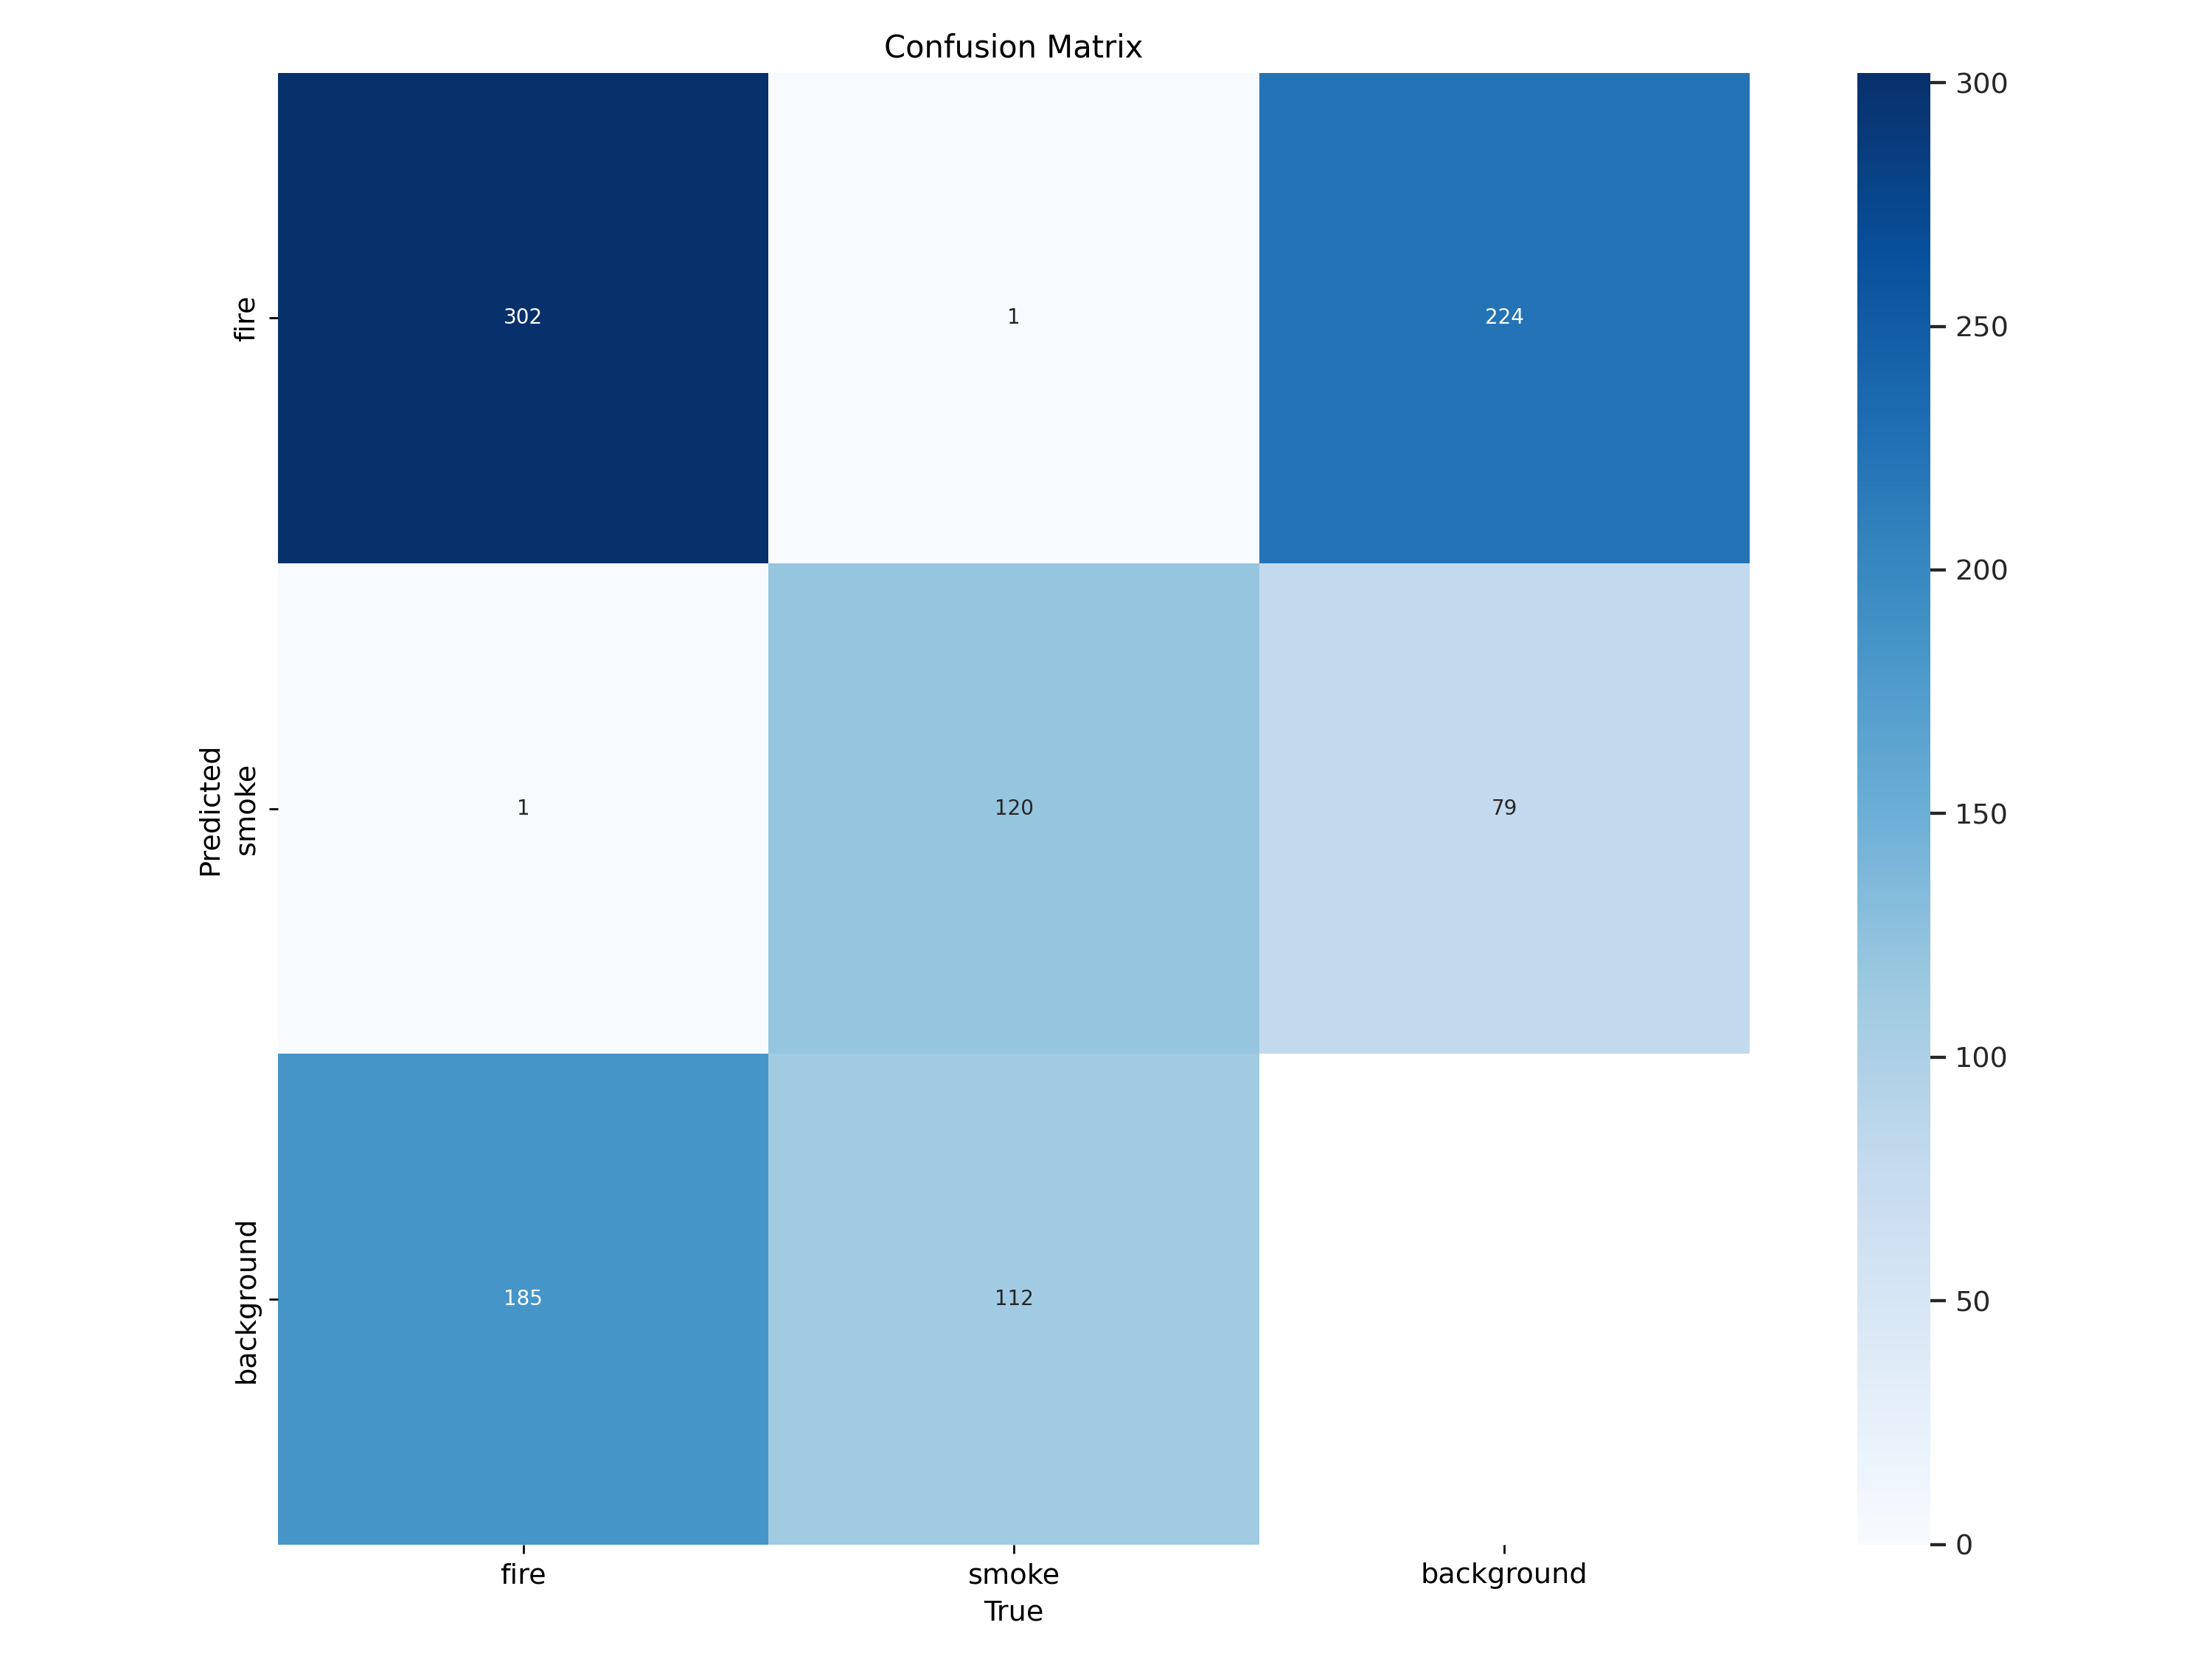

In [ ]:
# Take a look at the confusion matrix of training results
from IPython.display import Image
%cd {HOME}
Image(filename=f'{HOME}/runs/detect/train5/confusion_matrix.png', width=600)

In [ ]:
# Load newly trained model

import supervision as sv

model = YOLOv10(f'{HOME}/runs/detect/train5/weights/best.pt')

dataset = sv.DetectionDataset.from_yolo(
    #images_directory_path=f"{dataset.location}/valid/images",
    images_directory_path="/content/datasets/Fire-Smoke-Detection-3/valid/images",
    annotations_directory_path="/content/datasets/Fire-Smoke-Detection-3/valid/labels",
    data_yaml_path="/content/datasets/Fire-Smoke-Detection-3/data.yaml"
)

bounding_box_annotator = sv.BoundingBoxAnnotator()
label_annotator = sv.LabelAnnotator()


0: 640x640 3 fires, 1 smoke, 20.5ms
Speed: 2.3ms preprocess, 20.5ms inference, 1.7ms postprocess per image at shape (1, 3, 640, 640)


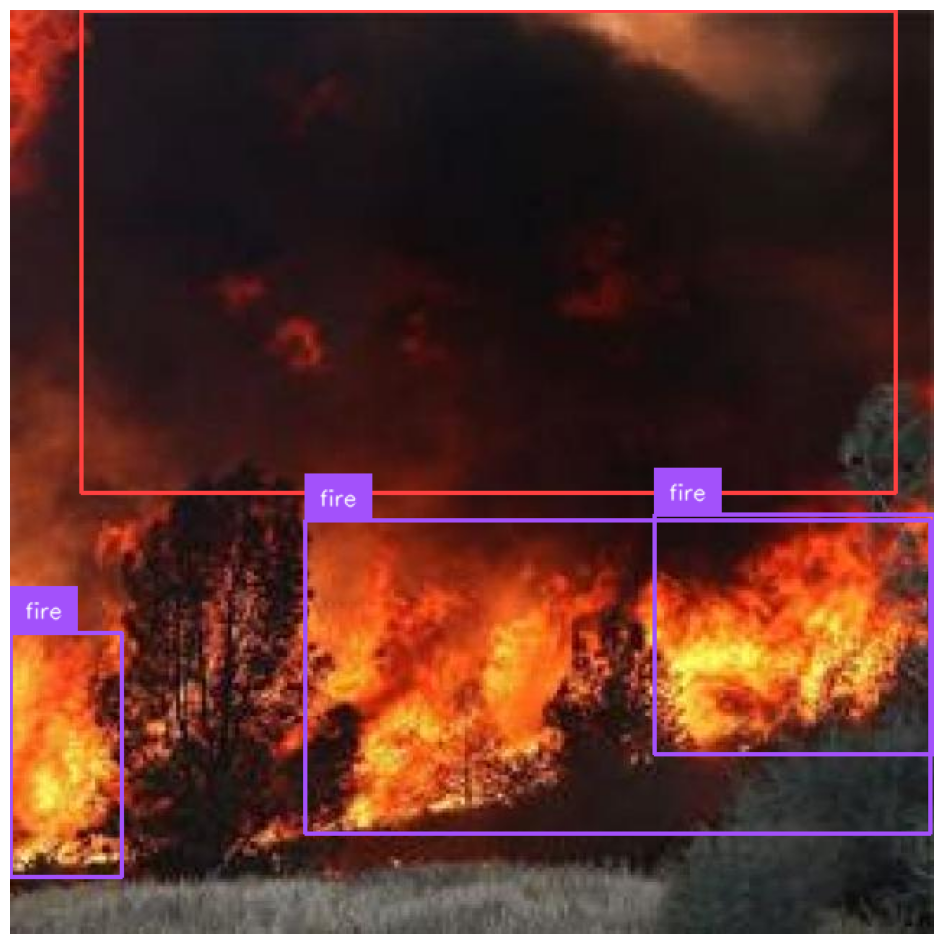

In [ ]:
# Randomly select image from validation set and visualize the results

import random

random_image = random.choice(list(dataset.images.keys()))
random_image = dataset.images[random_image]

results = model(source=random_image, conf=0.25)[0]
detections = sv.Detections.from_ultralytics(results)

annotated_image = bounding_box_annotator.annotate(
    scene=random_image, detections=detections)
annotated_image = label_annotator.annotate(
    scene=annotated_image, detections=detections)

sv.plot_image(annotated_image)

In [4]:
# ============================================================
# CASE STUDY - STEP 0 & QUESTION 1
# Goal:
# 1) Load the correct file: Test.csv
# 2) Understand the dataset structure
# 3) Check whether the data is evenly sampled
# 4) Estimate the sampling frequency
# ============================================================
import pandas as pd
import numpy as np
# ------------------------------------------------------------
# 1. Load the dataset
# ------------------------------------------------------------
# The case study explicitly asks us to use Test.csv
file_path = "Test (1).csv"
df = pd.read_csv(file_path)
print("✅ Dataset loaded successfully")
print("Shape of dataset:", df.shape)
print("\nFirst 5 rows:")
display(df.head())
# ------------------------------------------------------------
# 2. Check columns and data types
# ------------------------------------------------------------
print("\nColumn names:")
print(df.columns)
print("\nDataset information:")
df.info()
# ------------------------------------------------------------
# 3. Convert Timestamp column to datetime
# ------------------------------------------------------------
df["Timestamp"] = pd.to_datetime(df["Timestamp"])
print("\n✅ Timestamp converted to datetime")
print("Timestamp range:")
print("Start:", df["Timestamp"].min())
print("End  :", df["Timestamp"].max())
# ------------------------------------------------------------
# 4. Compute time difference between consecutive samples
# ------------------------------------------------------------
dt = df["Timestamp"].diff().dropna()
print("\nFirst 10 time differences:")
print(dt.head(10))
# Convert time differences to seconds
dt_seconds = dt.dt.total_seconds()
# ------------------------------------------------------------
# 5. Check if sampling is even
# ------------------------------------------------------------
print("\nTime-step statistics in seconds:")
print(dt_seconds.describe())
print("\nUnique time steps:")
print(dt_seconds.value_counts().head(10))
# ------------------------------------------------------------
# 6. Estimate sampling period and frequency
# ------------------------------------------------------------
mean_dt = dt_seconds.mean()
std_dt = dt_seconds.std()
fs = 1 / mean_dt
print("\nEstimated sampling period Δt:", mean_dt, "seconds")
print("Standard deviation of Δt:", std_dt, "seconds")
print("Estimated sampling frequency fs:", fs, "Hz")
# ------------------------------------------------------------
# 7. Conclusion
# ------------------------------------------------------------
tolerance = 1e-6
if std_dt < tolerance:
   print("\n✅ Conclusion: The data appears evenly sampled.")
else:
   print("\n⚠️ Conclusion: The data may not be perfectly evenly sampled.")
print("\nInterview explanation:")
print(
   "I checked even sampling by computing the time difference between consecutive timestamps. "
   "If the time step is constant or has very small variation, the data is evenly sampled. "
   "The sampling frequency is calculated as fs = 1 / mean(Δt)."
)

✅ Dataset loaded successfully
Shape of dataset: (1339471, 3)

First 5 rows:


,Timestamp,Acceleration,Load
0,2020-12-25 00:00:00.165876124,9.395560,10859.135636
1,2020-12-25 00:00:00.265876124,9.410613,11073.020529
2,2020-12-25 00:00:00.365876124,9.446886,11244.556897
3,2020-12-25 00:00:00.465876124,9.453507,11098.952087
4,2020-12-25 00:00:00.565876124,9.459676,10838.190138



Column names:
Index(['Timestamp', 'Acceleration', 'Load'], dtype='object')

Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1339471 entries, 0 to 1339470
Data columns (total 3 columns):
 #   Column        Non-Null Count    Dtype  
---  ------        --------------    -----  
 0   Timestamp     1339471 non-null  object 
 1   Acceleration  1339471 non-null  float64
 2   Load          1339470 non-null  float64
dtypes: float64(2), object(1)
memory usage: 30.7+ MB

✅ Timestamp converted to datetime
Timestamp range:
Start: 2020-12-25 00:00:00.165876124
End  : 2020-12-26 13:12:27.165876124

First 10 time differences:
1    0 days 00:00:00.100000
2    0 days 00:00:00.100000
3    0 days 00:00:00.100000
4    0 days 00:00:00.100000
5    0 days 00:00:00.100000
6    0 days 00:00:00.100000
7    0 days 00:00:00.100000
8    0 days 00:00:00.100000
9    0 days 00:00:00.100000
10   0 days 00:00:00.100000
Name: Timestamp, dtype: timedelta64[ns]

Time-step statistics in seconds:
coun

Rolling std computed


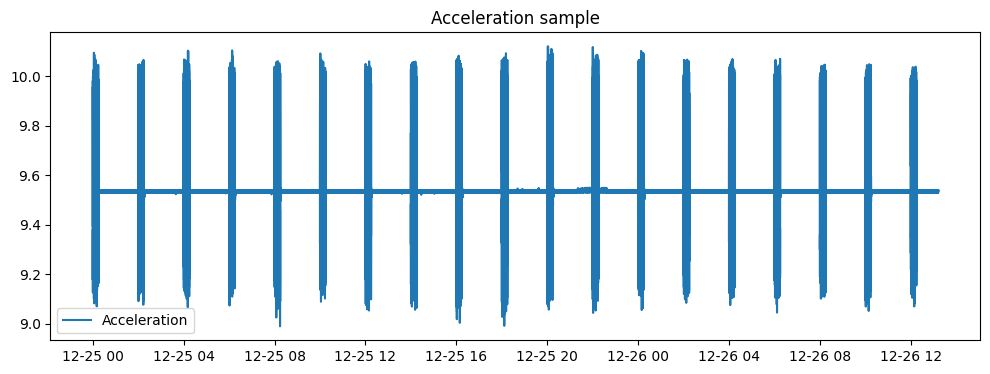

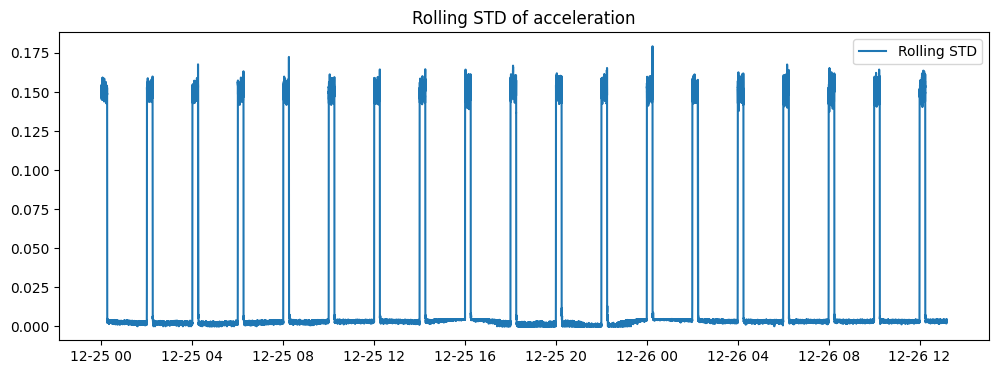

In [6]:
# ------------------------------------------------------------
# Question 2 - Detect running vs stopped
# ------------------------------------------------------------
# Compute rolling standard deviation
window = 100  # 10 seconds window (since fs = 10 Hz)
df["acc_std"] = df["Acceleration"].rolling(window).std()
print("Rolling std computed")
# Plot a small segment
import matplotlib.pyplot as plt
plt.figure(figsize=(12,4))
plt.plot(df["Timestamp"][:], df["Acceleration"][:], label="Acceleration")
plt.title("Acceleration sample")
plt.legend()
plt.show()
plt.figure(figsize=(12,4))
plt.plot(df["Timestamp"][:], df["acc_std"][:], label="Rolling STD")
plt.title("Rolling STD of acceleration")
plt.legend()
plt.show()

Data prepared for clustering: (1339372, 1)
Clustering completed

Cluster means (important!):
cluster
0.0    0.002939
1.0    0.150998
Name: acc_std, dtype: float64

Cluster identified as RUNNING: 1.0

Running signal created


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


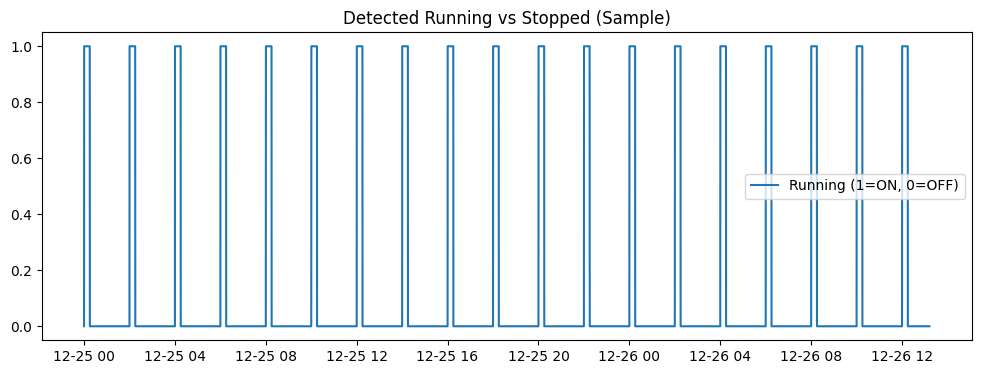

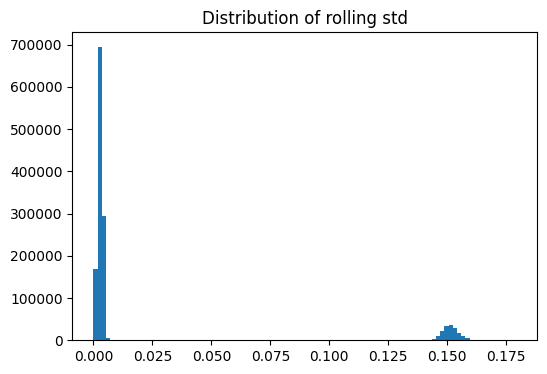

In [10]:
# ============================================================
# ROBUST ON/OFF DETECTION USING K-MEANS CLUSTERING
# ============================================================
from sklearn.cluster import KMeans
import numpy as np
import matplotlib.pyplot as plt
# ------------------------------------------------------------
# 1. Prepare data (remove NaNs)
# ------------------------------------------------------------
acc_std_clean = df["acc_std"].dropna().values.reshape(-1, 1)
print("Data prepared for clustering:", acc_std_clean.shape)
# ------------------------------------------------------------
# 2. Apply K-Means clustering (2 clusters: OFF vs ON)
# ------------------------------------------------------------
kmeans = KMeans(n_clusters=2, random_state=0, n_init=10)
labels = kmeans.fit_predict(acc_std_clean)
print("Clustering completed")
# ------------------------------------------------------------
# 3. Map clusters back to dataframe
# ------------------------------------------------------------
df["cluster"] = np.nan
df.loc[df["acc_std"].notna(), "cluster"] = labels
# ------------------------------------------------------------
# 4. Identify which cluster = ON (higher variance)
# ------------------------------------------------------------
cluster_means = df.groupby("cluster")["acc_std"].mean()
print("\nCluster means (important!):")
print(cluster_means)
# Cluster with higher std = running
on_cluster = cluster_means.idxmax()
print("\nCluster identified as RUNNING:", on_cluster)
# ------------------------------------------------------------
# 5. Create ON/OFF signal
# ------------------------------------------------------------
df["is_running"] = (df["cluster"] == on_cluster).astype(int)
print("\nRunning signal created")
# ------------------------------------------------------------
# 6. Quick visualization (VERY IMPORTANT)
# ------------------------------------------------------------
plt.figure(figsize=(12,4))
plt.plot(df["Timestamp"][:], df["is_running"][:], label="Running (1=ON, 0=OFF)")
plt.title("Detected Running vs Stopped (Sample)")
plt.legend()
plt.show()
# ------------------------------------------------------------
# 7. Optional: visualize distribution
# ------------------------------------------------------------
plt.figure(figsize=(6,4))
plt.hist(df["acc_std"].dropna(), bins=100)
plt.title("Distribution of rolling std")
plt.show()

Threshold value: 0.12118058343158383
Threshold-based running signal created


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


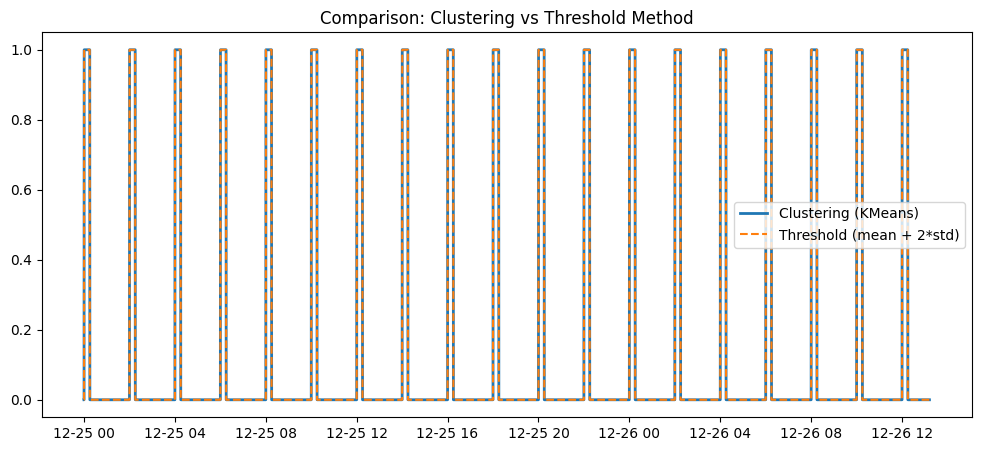

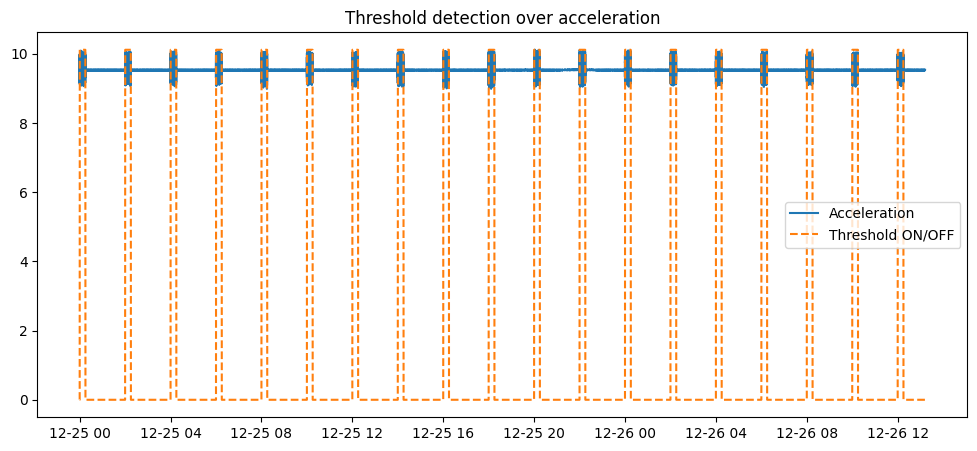

In [13]:
# ============================================================
# THRESHOLD METHOD (mean + 2*std)
# ============================================================
# 1. Compute threshold
threshold = df["acc_std"].mean() + 2 * df["acc_std"].std()
print("Threshold value:", threshold)
# 2. Create ON/OFF signal
df["is_running_threshold"] = (df["acc_std"] > threshold).astype(int)
print("Threshold-based running signal created")
# ------------------------------------------------------------
# 3. Compare with clustering (visual)
# ------------------------------------------------------------
plt.figure(figsize=(12,5))
plt.plot(df["Timestamp"][:], df["is_running"][:],
        label="Clustering (KMeans)", linewidth=2)
plt.plot(df["Timestamp"][:], df["is_running_threshold"][:],
        label="Threshold (mean + 2*std)", linestyle="--")
plt.title("Comparison: Clustering vs Threshold Method")
plt.legend()
plt.show()
# ------------------------------------------------------------
# 4. Optional: overlay on acceleration
# ------------------------------------------------------------
plt.figure(figsize=(12,5))
plt.plot(df["Timestamp"][:], df["Acceleration"][:], label="Acceleration")
plt.plot(df["Timestamp"][:],
        df["is_running_threshold"][:]*df["Acceleration"].max(),
        label="Threshold ON/OFF", linestyle="--")
plt.title("Threshold detection over acceleration")
plt.legend()
plt.show()

/tmp/ipykernel_1749/3439198656.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  plot_trimmed["Load"] = window_df["Load"].iloc[trim_samples:-trim_samples].values


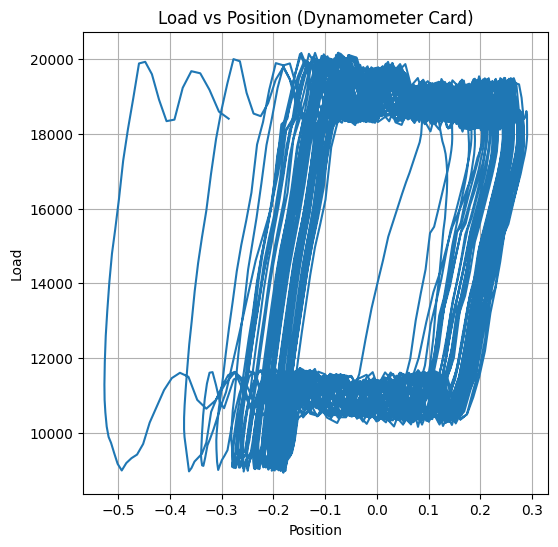

In [16]:
# ============================================================
# QUESTION 7 - Load vs Position (Dynamometer card)
# ============================================================
# Use trimmed data (same as Q6)
plot_trimmed["Load"] = window_df["Load"].iloc[trim_samples:-trim_samples].values
plt.figure(figsize=(6,6))
plt.plot(plot_trimmed["position"], plot_trimmed["Load"])
plt.title("Load vs Position (Dynamometer Card)")
plt.xlabel("Position")
plt.ylabel("Load")
plt.grid(True)
plt.show()

In [14]:
# ============================================================
# QUESTION 4 - Runtime estimation
# ============================================================
# 1. Create segments (if not already done)
df["segment"] = (df["is_running"].diff() != 0).cumsum()
segments = (
   df.groupby("segment")
     .agg(
         state=("is_running", "first"),
         start=("Timestamp", "first"),
         end=("Timestamp", "last")
     )
     .reset_index()
)
# Compute duration
segments["duration_sec"] = (segments["end"] - segments["start"]).dt.total_seconds()
# ------------------------------------------------------------
# 2. Remove long OFF periods (> 12 hours)
# ------------------------------------------------------------
long_off_threshold = 12 * 3600  # seconds
segments_filtered = segments[
   ~((segments["state"] == 0) & (segments["duration_sec"] > long_off_threshold))
]
print("Filtered segments:")
display(segments_filtered.head())
# ------------------------------------------------------------
# 3. Compute runtime
# ------------------------------------------------------------
total_time = segments_filtered["duration_sec"].sum()
running_time = segments_filtered[
   segments_filtered["state"] == 1
]["duration_sec"].sum()
runtime_ratio = running_time / total_time
print("\nTotal considered time (s):", total_time)
print("Running time (s):", running_time)
print("Runtime ratio:", runtime_ratio)

Filtered segments:


,segment,state,start,end,duration_sec
0,1,0,2020-12-25 00:00:00.165876124,2020-12-25 00:00:09.965876124,9.8
1,2,1,2020-12-25 00:00:10.065876124,2020-12-25 00:15:11.165876124,901.1
2,3,0,2020-12-25 00:15:11.265876124,2020-12-25 02:00:04.365876124,6293.1
3,4,1,2020-12-25 02:00:04.465876124,2020-12-25 02:15:09.965876124,905.5
4,5,0,2020-12-25 02:15:10.065876124,2020-12-25 04:00:04.565876124,6294.5



Total considered time (s): 133943.19999999998
Running time (s): 17202.000000000004
Runtime ratio: 0.12842757228437132


Window shape: (6000, 8)
Start: 2020-12-25 02:01:00.065876124
End: 2020-12-25 02:10:59.965876124


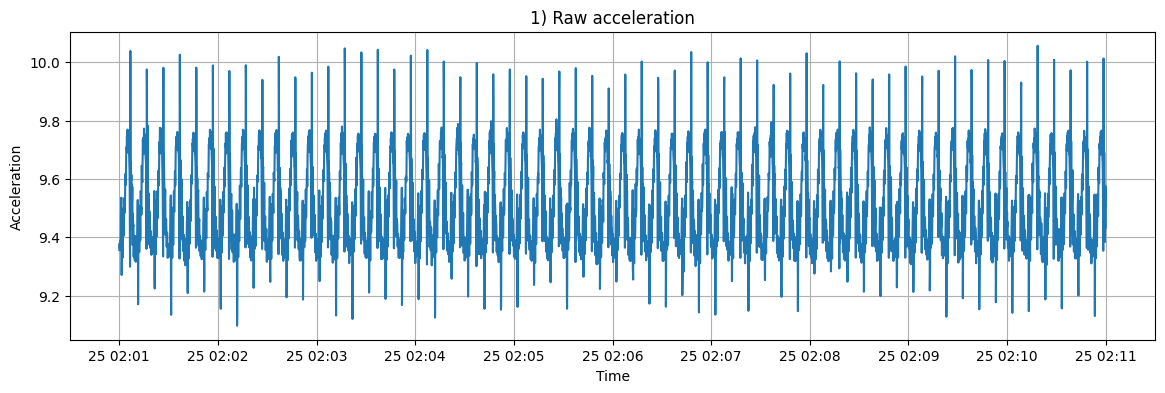

Raw acceleration mean: 9.514112895156984


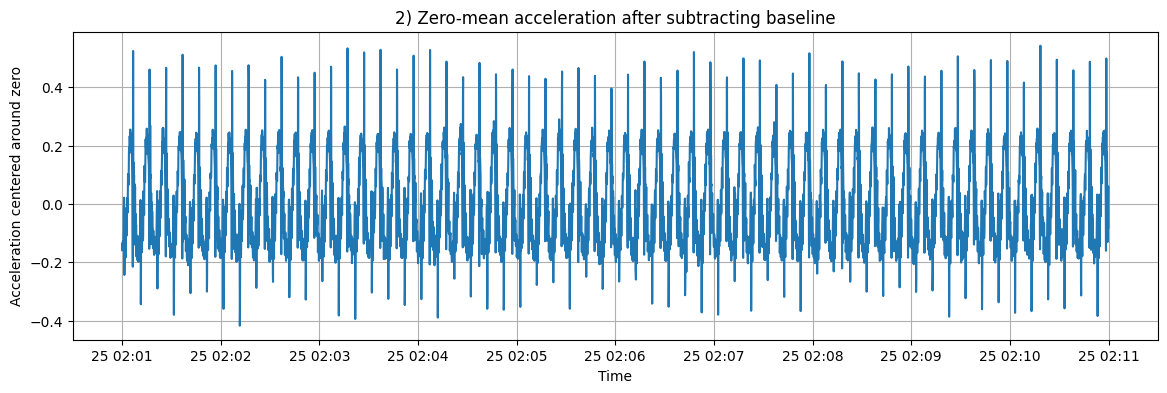

Baseline removed: 9.514112895156984
Zero-mean acceleration mean: 6.498505437472583e-16
Sampling frequency: 10.0 Hz
Nyquist frequency: 5.0 Hz
Band-pass filter range: 0.05 - 0.1 Hz


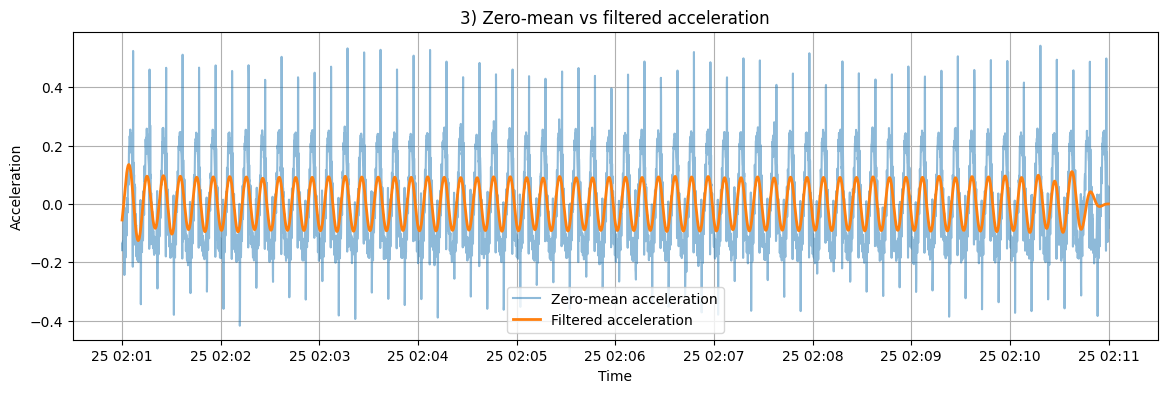

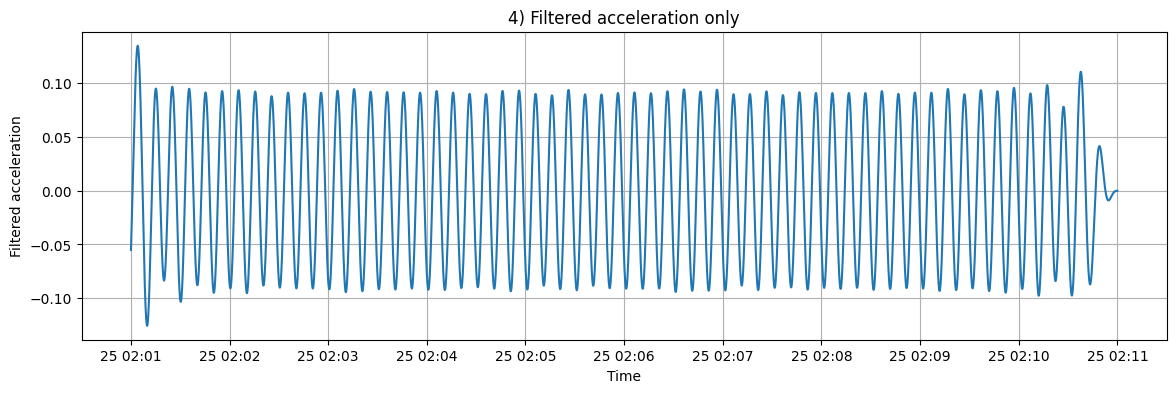

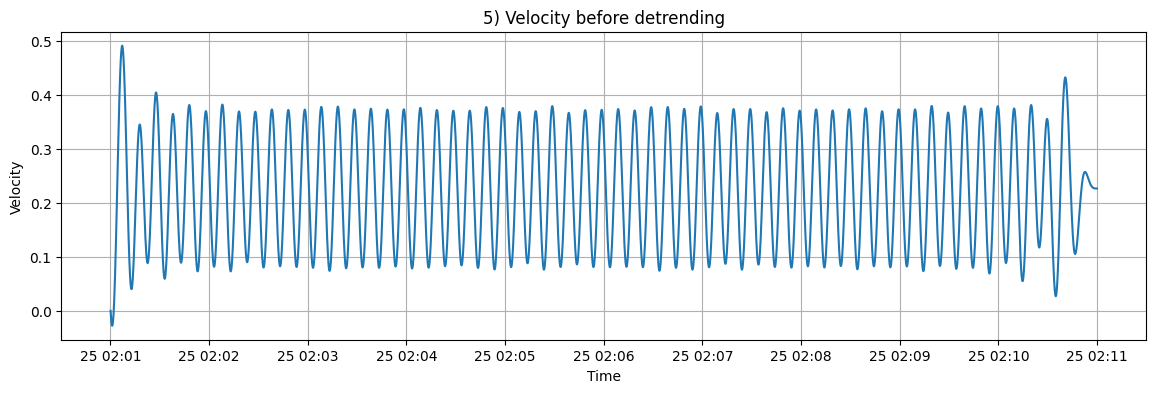

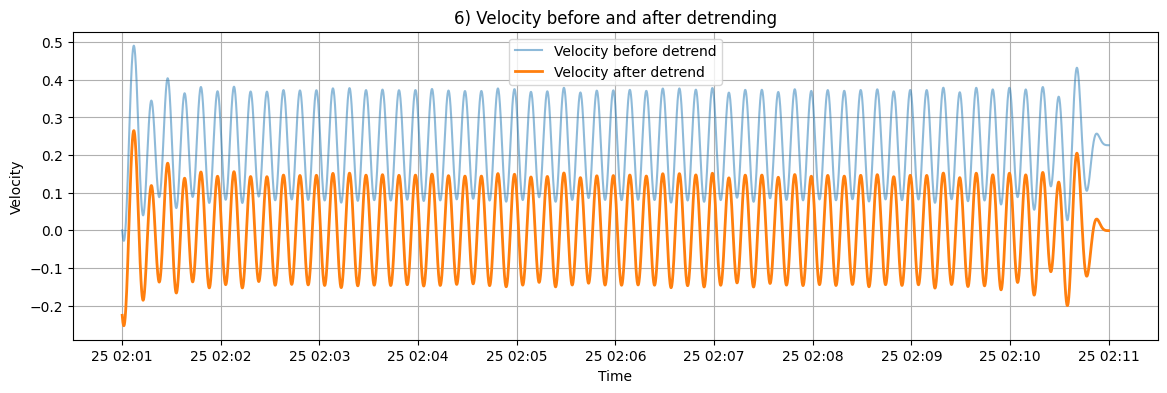

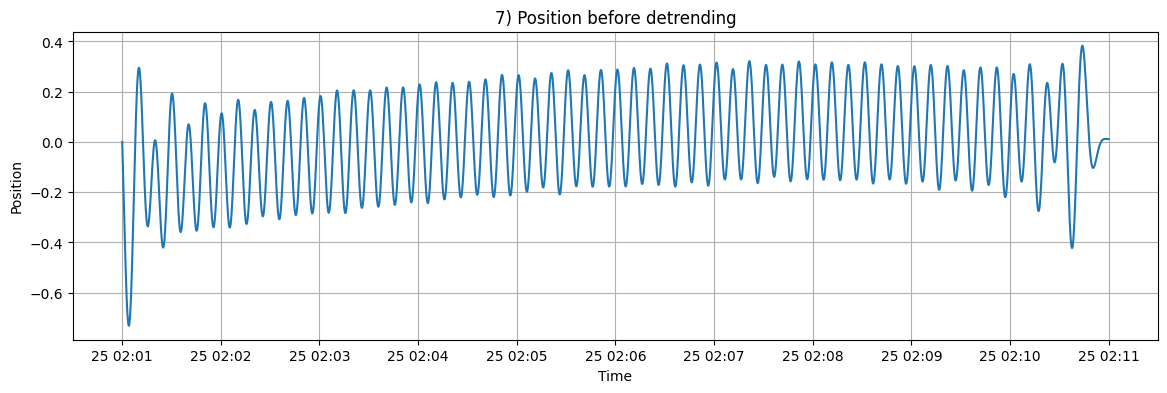

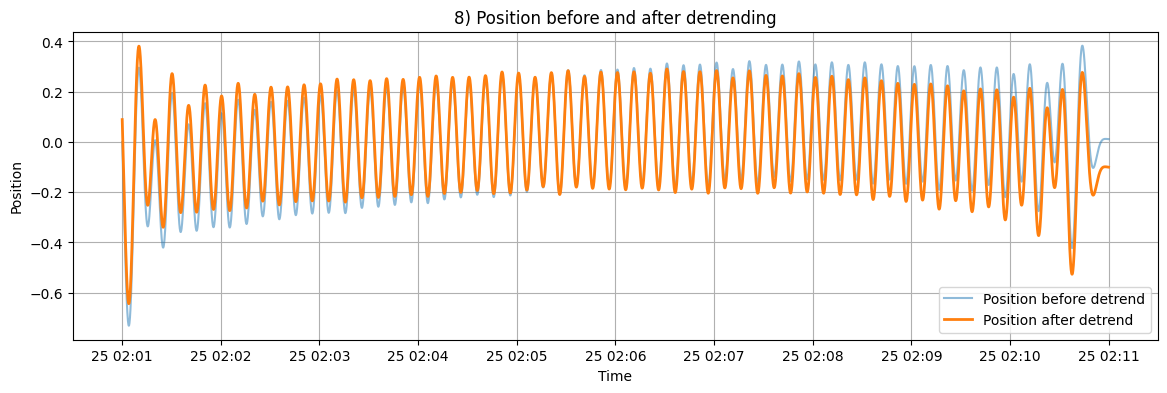

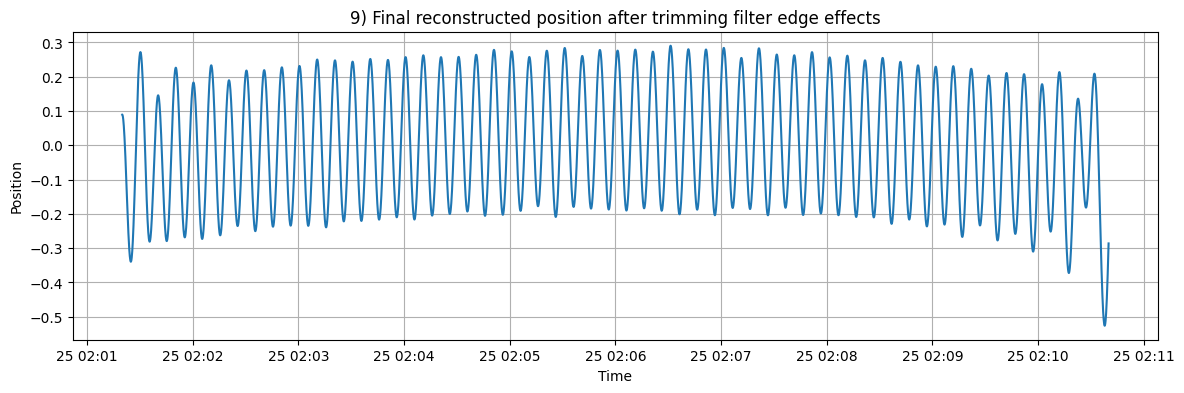

Estimated stroke amplitude after trimming: 0.8170031936060883


In [15]:
# ============================================================
# QUESTION 6 - Step-by-step position reconstruction
# Using pump frequency band: 0.05 - 0.1 Hz
# ============================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt, detrend
from scipy.integrate import cumulative_trapezoid
fs = 10.0
dt = 1 / fs
start_time = pd.to_datetime("2020-12-25T02:01:00")
end_time   = pd.to_datetime("2020-12-25T02:11:00")
window_df = df[(df["Timestamp"] >= start_time) &
              (df["Timestamp"] <= end_time)].copy()
t = window_df["Timestamp"]
a_raw = window_df["Acceleration"].values
print("Window shape:", window_df.shape)
print("Start:", window_df["Timestamp"].min())
print("End:", window_df["Timestamp"].max())
# ------------------------------------------------------------
# 1. Raw acceleration
# ------------------------------------------------------------
plt.figure(figsize=(14,4))
plt.plot(t, a_raw)
plt.title("1) Raw acceleration")
plt.xlabel("Time")
plt.ylabel("Acceleration")
plt.grid(True)
plt.show()
print("Raw acceleration mean:", np.mean(a_raw))
# ------------------------------------------------------------
# 2. Remove baseline
# Baseline ≈ gravity + sensor offset
# ------------------------------------------------------------
baseline = np.mean(a_raw)
a_zero = a_raw - baseline
plt.figure(figsize=(14,4))
plt.plot(t, a_zero)
plt.title("2) Zero-mean acceleration after subtracting baseline")
plt.xlabel("Time")
plt.ylabel("Acceleration centered around zero")
plt.grid(True)
plt.show()
print("Baseline removed:", baseline)
print("Zero-mean acceleration mean:", np.mean(a_zero))
# ------------------------------------------------------------
# 3. Band-pass filter
# We keep only the expected pump frequency range: 0.05 - 0.1 Hz
# ------------------------------------------------------------
lowcut = 0.05
highcut = 0.10
nyquist = fs / 2
print("Sampling frequency:", fs, "Hz")
print("Nyquist frequency:", nyquist, "Hz")
print("Band-pass filter range:", lowcut, "-", highcut, "Hz")
b, a = butter(
   N=4,
   Wn=[lowcut / nyquist, highcut / nyquist],
   btype="band"
)
a_filtered = filtfilt(b, a, a_zero)
plt.figure(figsize=(14,4))
plt.plot(t, a_zero, label="Zero-mean acceleration", alpha=0.5)
plt.plot(t, a_filtered, label="Filtered acceleration", linewidth=2)
plt.title("3) Zero-mean vs filtered acceleration")
plt.xlabel("Time")
plt.ylabel("Acceleration")
plt.legend()
plt.grid(True)
plt.show()
plt.figure(figsize=(14,4))
plt.plot(t, a_filtered)
plt.title("4) Filtered acceleration only")
plt.xlabel("Time")
plt.ylabel("Filtered acceleration")
plt.grid(True)
plt.show()
# ------------------------------------------------------------
# 4. Integrate acceleration -> velocity
# ------------------------------------------------------------
velocity_raw = cumulative_trapezoid(a_filtered, dx=dt, initial=0)
plt.figure(figsize=(14,4))
plt.plot(t, velocity_raw)
plt.title("5) Velocity before detrending")
plt.xlabel("Time")
plt.ylabel("Velocity")
plt.grid(True)
plt.show()
velocity_detrended = detrend(velocity_raw)
plt.figure(figsize=(14,4))
plt.plot(t, velocity_raw, label="Velocity before detrend", alpha=0.5)
plt.plot(t, velocity_detrended, label="Velocity after detrend", linewidth=2)
plt.title("6) Velocity before and after detrending")
plt.xlabel("Time")
plt.ylabel("Velocity")
plt.legend()
plt.grid(True)
plt.show()
# ------------------------------------------------------------
# 5. Integrate velocity -> position
# ------------------------------------------------------------
position_raw = cumulative_trapezoid(velocity_detrended, dx=dt, initial=0)
plt.figure(figsize=(14,4))
plt.plot(t, position_raw)
plt.title("7) Position before detrending")
plt.xlabel("Time")
plt.ylabel("Position")
plt.grid(True)
plt.show()
position_detrended = detrend(position_raw)
position_detrended = position_detrended - np.mean(position_detrended)
plt.figure(figsize=(14,4))
plt.plot(t, position_raw, label="Position before detrend", alpha=0.5)
plt.plot(t, position_detrended, label="Position after detrend", linewidth=2)
plt.title("8) Position before and after detrending")
plt.xlabel("Time")
plt.ylabel("Position")
plt.legend()
plt.grid(True)
plt.show()
# ------------------------------------------------------------
# 6. Trim edge effects for interpretation
# ------------------------------------------------------------
trim_seconds = 20
trim_samples = int(trim_seconds * fs)
plot_df = window_df.copy()
plot_df["position"] = position_detrended
plot_trimmed = plot_df.iloc[trim_samples:-trim_samples]
plt.figure(figsize=(14,4))
plt.plot(plot_trimmed["Timestamp"], plot_trimmed["position"])
plt.title("9) Final reconstructed position after trimming filter edge effects")
plt.xlabel("Time")
plt.ylabel("Position")
plt.grid(True)
plt.show()
stroke_amplitude = (
   plot_trimmed["position"].max() - plot_trimmed["position"].min()
)
print("Estimated stroke amplitude after trimming:", stroke_amplitude)

Detected cycles: 54


/tmp/ipykernel_1749/3654767028.py:40: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  card_area = np.abs(np.trapz(l, p))


,cycle_id,start_time,end_time,duration_sec,position_range,load_range,load_mean,load_std,card_area,branch_asymmetry,top_fluctuation,bottom_fluctuation,transition_drop,left_load_drop,right_load_drop,transition_asymmetry,high_to_low_energy
0,0,2020-12-25 02:01:30.365876124,2020-12-25 02:01:40.365876124,10.0,0.553054,10791.026933,14637.166337,3773.585416,1314.693690,4523.713887,417.475495,598.426837,1920.333657,3033.114817,2841.949672,191.165145,0.347580
1,1,2020-12-25 02:01:40.465876124,2020-12-25 02:01:50.365876124,9.9,0.505275,10962.361363,14610.131666,3780.742183,4005.522983,4736.425128,417.471888,603.051122,1816.905323,1081.053211,1269.728320,188.675109,0.719900
2,2,2020-12-25 02:01:50.465876124,2020-12-25 02:02:00.365876124,9.9,0.495155,11060.660234,14612.542069,3776.047175,2347.965636,4601.096380,427.447920,598.883426,1953.958147,2022.618666,2338.213308,315.594641,0.713317
3,3,2020-12-25 02:02:00.465876124,2020-12-25 02:02:10.465876124,10.0,0.505926,10825.812874,14647.726927,3774.110496,3707.665535,4509.567296,410.944639,606.429324,1956.253442,1605.197653,1352.365318,252.832335,0.342904
4,4,2020-12-25 02:02:10.565876124,2020-12-25 02:02:20.565876124,10.0,0.496082,11118.535017,14644.652659,3780.757013,2440.820020,4752.900557,433.615104,610.784635,1857.457436,2221.215121,2877.020214,655.805093,0.345426


Number of cycles: 54

Cluster counts:
cluster
2    30
1    23
0     1
Name: count, dtype: int64

Cluster means:


,duration_sec,position_range,load_range,load_mean,load_std,card_area,branch_asymmetry,top_fluctuation,bottom_fluctuation,transition_drop,transition_asymmetry,high_to_low_energy
cluster,,,,,,,,,,,,
0,9.200000,0.390553,11248.822021,14363.616742,3838.817316,3458.289005,5627.575765,431.211794,590.564209,1902.221171,407.202399,0.675521
1,10.034783,0.492251,10972.709207,14652.004134,3783.140117,2925.507749,4627.030216,425.243401,609.748952,1947.111636,268.068428,0.351264
2,9.873333,0.466543,10979.776269,14597.919539,3789.186118,2916.289935,4714.177784,416.866958,601.002633,1923.830762,318.076590,0.714690


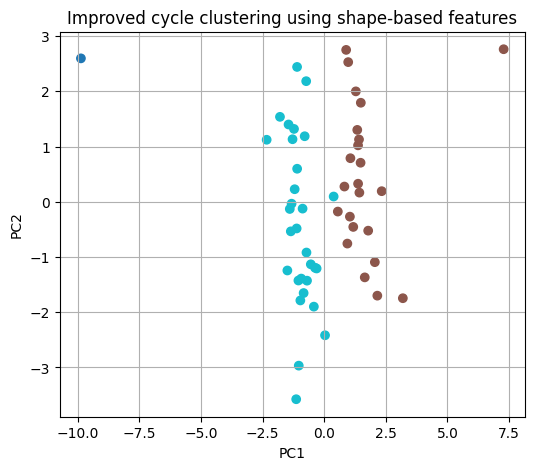

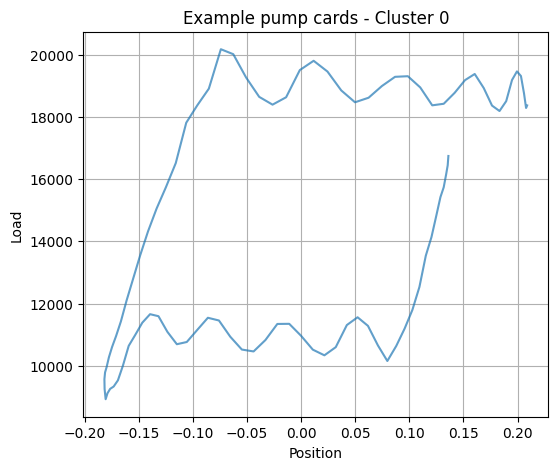

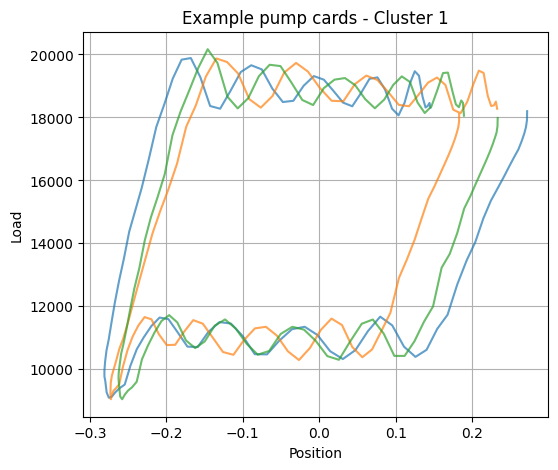

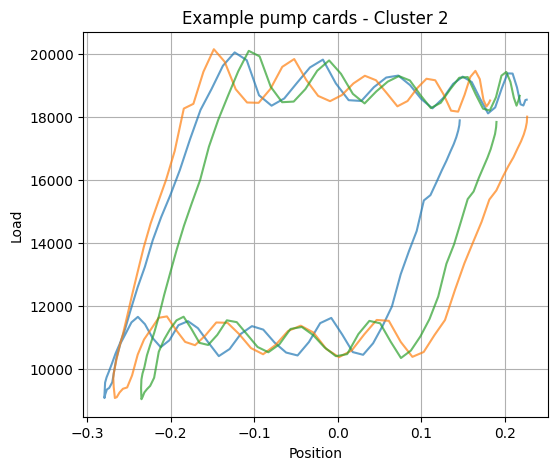

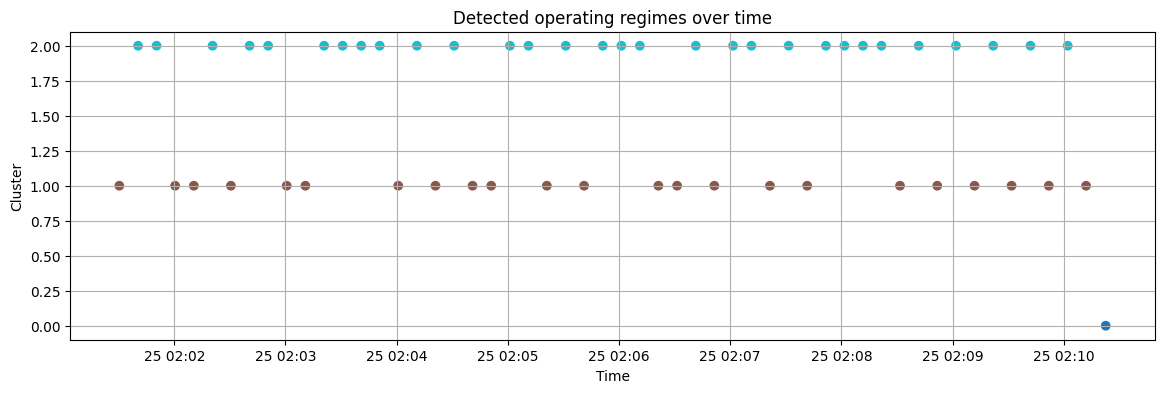

In [18]:
# ============================================================
# Q9 - Improved cycle clustering with shape-based features
# ============================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import find_peaks
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
q9_df = plot_trimmed.copy().dropna(subset=["Timestamp", "position", "Load"])
pos = q9_df["position"].values
load = q9_df["Load"].values
fs = 10
# ------------------------------------------------------------
# 1. Segment cycles using position peaks
# ------------------------------------------------------------
min_distance = int(8 * fs)
peaks, _ = find_peaks(pos, distance=min_distance)
print("Detected cycles:", len(peaks) - 1)
# ------------------------------------------------------------
# 2. Extract richer physical + shape features
# ------------------------------------------------------------
features = []
for i in range(len(peaks) - 1):
   s = peaks[i]
   e = peaks[i + 1]
   cycle = q9_df.iloc[s:e].copy()
   if len(cycle) < 30:
       continue
   p = cycle["position"].values
   l = cycle["Load"].values
   t = cycle["Timestamp"]
   duration = (t.iloc[-1] - t.iloc[0]).total_seconds()
   # Basic features
   pos_range = p.max() - p.min()
   load_range = l.max() - l.min()
   load_mean = l.mean()
   load_std = l.std()
   card_area = np.abs(np.trapz(l, p))
   # --------------------------------------------------------
   # Shape features
   # --------------------------------------------------------
   # Split cycle into two halves as proxy for upstroke/downstroke
   mid = len(cycle) // 2
   l_first = l[:mid]
   l_second = l[mid:]
   p_first = p[:mid]
   p_second = p[mid:]
   # Branch asymmetry: load difference between two halves
   branch_asymmetry = abs(l_first.mean() - l_second.mean())
   # Top and bottom fluctuations
   top_threshold = np.percentile(l, 75)
   bottom_threshold = np.percentile(l, 25)
   top_load = l[l >= top_threshold]
   bottom_load = l[l <= bottom_threshold]
   top_fluctuation = np.std(top_load) if len(top_load) > 2 else 0
   bottom_fluctuation = np.std(bottom_load) if len(bottom_load) > 2 else 0
   # Transition drop: difference between minimum load and lower quartile
   transition_drop = np.percentile(l, 25) - l.min()
   # Left/right transition slope approximation
   # Sort by position to look at load changes near left and right boundaries
   left_mask = p <= np.percentile(p, 10)
   right_mask = p >= np.percentile(p, 90)
   left_load_drop = l[left_mask].max() - l[left_mask].min() if left_mask.sum() > 2 else 0
   right_load_drop = l[right_mask].max() - l[right_mask].min() if right_mask.sum() > 2 else 0
   transition_asymmetry = abs(left_load_drop - right_load_drop)
   # Frequency-domain feature on load
   l_centered = l - l.mean()
   fft_vals = np.abs(np.fft.rfft(l_centered))
   fft_freqs = np.fft.rfftfreq(len(l_centered), d=1/fs)
   # Energy in low band around pump cycle and higher band vibration
   low_band = (fft_freqs >= 0.05) & (fft_freqs <= 0.3)
   high_band = (fft_freqs > 0.3) & (fft_freqs <= 2.0)
   low_energy = fft_vals[low_band].sum()
   high_energy = fft_vals[high_band].sum()
   high_to_low_energy = high_energy / (low_energy + 1e-8)
   features.append({
       "cycle_id": i,
       "start_time": t.iloc[0],
       "end_time": t.iloc[-1],
       "duration_sec": duration,
       "position_range": pos_range,
       "load_range": load_range,
       "load_mean": load_mean,
       "load_std": load_std,
       "card_area": card_area,
       "branch_asymmetry": branch_asymmetry,
       "top_fluctuation": top_fluctuation,
       "bottom_fluctuation": bottom_fluctuation,
       "transition_drop": transition_drop,
       "left_load_drop": left_load_drop,
       "right_load_drop": right_load_drop,
       "transition_asymmetry": transition_asymmetry,
       "high_to_low_energy": high_to_low_energy
   })
cycle_features2 = pd.DataFrame(features)
display(cycle_features2.head())
print("Number of cycles:", len(cycle_features2))
# ------------------------------------------------------------
# 3. Cluster cycles
# ------------------------------------------------------------
feature_cols = [
   "duration_sec",
   "position_range",
   "load_range",
   "load_mean",
   "load_std",
   "card_area",
   "branch_asymmetry",
   "top_fluctuation",
   "bottom_fluctuation",
   "transition_drop",
   "transition_asymmetry",
   "high_to_low_energy"
]
X = cycle_features2[feature_cols].replace([np.inf, -np.inf], np.nan).fillna(0)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
k = 3
kmeans = KMeans(n_clusters=k, random_state=0, n_init=10)
cycle_features2["cluster"] = kmeans.fit_predict(X_scaled)
print("\nCluster counts:")
print(cycle_features2["cluster"].value_counts())
print("\nCluster means:")
display(cycle_features2.groupby("cluster")[feature_cols].mean())
# ------------------------------------------------------------
# 4. PCA visualization
# ------------------------------------------------------------
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
plt.figure(figsize=(6,5))
plt.scatter(X_pca[:,0], X_pca[:,1], c=cycle_features2["cluster"], cmap="tab10")
plt.title("Improved cycle clustering using shape-based features")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.grid(True)
plt.show()
# ------------------------------------------------------------
# 5. Plot example cards per cluster
# ------------------------------------------------------------
for cluster_id in sorted(cycle_features2["cluster"].unique()):
   examples = cycle_features2[cycle_features2["cluster"] == cluster_id].head(3)
   plt.figure(figsize=(6,5))
   for _, row in examples.iterrows():
       cycle_df = q9_df[
           (q9_df["Timestamp"] >= row["start_time"]) &
           (q9_df["Timestamp"] <= row["end_time"])
       ]
       plt.plot(cycle_df["position"], cycle_df["Load"], alpha=0.7)
   plt.title(f"Example pump cards - Cluster {cluster_id}")
   plt.xlabel("Position")
   plt.ylabel("Load")
   plt.grid(True)
   plt.show()
# ------------------------------------------------------------
# 6. Clusters over time
# ------------------------------------------------------------
plt.figure(figsize=(14,4))
plt.scatter(
   cycle_features2["start_time"],
   cycle_features2["cluster"],
   c=cycle_features2["cluster"],
   cmap="tab10"
)
plt.title("Detected operating regimes over time")
plt.xlabel("Time")
plt.ylabel("Cluster")
plt.grid(True)
plt.show()